# 实验 3：RoPE 原理——相对位置与复数表示


## 1. 不考虑位置编码时的注意力分数

先暂时不考虑任何位置编码。对于两个 token，我们用它们对应的查询向量 $q$ 和键向量 $k$ 来计算原始注意力分数：

$$
s=q^\top k
$$

这个分数只取决于 $q$ 和 $k$ 本身，而与它们在序列中的位置无关。

例如，token A 和 token B 原本分别位于位置 1 和位置 5，它们的注意力分数是

$$
q_A^\top k_B
$$

如果把这两个 token 移到位置 10 和位置 20，只要它们对应的向量没有改变，得到的仍然是

$$
q_A^\top k_B
$$

因此，在不考虑位置编码的情况下，attention 只能感受到两个 token 在内容上的相关性，却感受不到它们的位置不同所带来的影响。

如果希望 attention 感受到 token 的位置信息，我们就需要让位置参与两个 token 的相关性计算。也就是说，希望两个 token 的原始注意力分数不仅取决于它们对应的 Q 和 K，还与它们在序列中的位置有关：

$$
s=f(q,k,m,n)
$$

其中 $m$ 和 $n$ 分别表示两个 token 的位置。

RoPE 所采用的思路，就是让位置通过对 Q 和 K 的旋转进入这一计算过程。


## 2. 用旋转编码位置

先从一个二维向量开始。设一个 token 的表示为

$$
x=
\begin{bmatrix}
x_1\\
x_2
\end{bmatrix}
$$

我们可以通过旋转这个向量来编码它所处的位置。设 token 位于位置 $m$，每向后移动一个位置就旋转固定的角度 $\theta$，那么位置 $m$ 对应的旋转角度为

$$
\phi_m=m\theta
$$

于是，该 token 在位置 $m$ 时的表示可以写成

$$
x_m=R(m\theta)x
$$

其中 $R(\phi)$ 表示将二维向量旋转 $\phi$ 角度的旋转矩阵

这样，同一个向量处于不同位置时，会对应不同的旋转角度，从而得到不同的表示。位置就通过向量方向的变化被编码了下来。

### 2.1 旋转后的 Q 和 K

现在把这种旋转应用到 Q 和 K 上。设位置 $m$ 的 token 对应查询向量 $q_m$，位置 $n$ 的 token 对应键向量 $k_n$。在不考虑位置编码时，它们的原始注意力分数为

$$
s_{mn}=q_m^\top k_n
$$

加入位置旋转后，Q 和 K 分别变为

$$
q_m'=R(m\theta)q_m
$$

$$
k_n'=R(n\theta)k_n
$$

因此，加入 RoPE 后的注意力分数为

$$
s_{mn}'=q_m'^\top k_n'
$$

也就是

$$
s_{mn}'
=
\bigl(R(m\theta)q_m\bigr)^\top
\bigl(R(n\theta)k_n\bigr)
$$

利用旋转矩阵满足

$$
R(\phi)^\top=R(-\phi)
$$

可以得到

$$
s_{mn}'
=
q_m^\top R(-m\theta)R(n\theta)k_n
$$

而二维旋转满足

$$
R(a)R(b)=R(a+b)
$$

因此

$$
\boxed{
s_{mn}'
=
q_m^\top R\bigl((n-m)\theta\bigr)k_n
}
$$

可以看到，加入 RoPE 后，注意力分数不仅取决于 $q_m$ 和 $k_n$ 的内容，还与两个 token 的位置有关，而且位置最终以它们的差 $n-m$ 出现

<p align="center">
  <img src="../assets/rope_demo.gif" alt="RoPE 演示" width="90%">
</p>

对比第一图可以看到，引入旋转位置编码后，注意力分数立刻发生了改变（如第二图）；更重要的是，随着 Token 位置的调换，计算出的分数也会随之变化（如第三图）。attention 成功感知了 token 不同位置的差异。

## 3. 相对位置

前面的推导表明，加入 RoPE 后，Q 和 K 的旋转会使注意力分数中出现两个位置之差 $n-m$。

为了直观地观察这一性质，下面固定一个查询向量 $q$ 和一个键向量 $k$，让它们分别位于位置 $m,n\in{0,1,\ldots,6}$。对于每一组位置，按照 RoPE 的方式分别旋转 Q 和 K，再计算旋转后的内积，得到一个 $7\times7$ 的注意力分数矩阵。

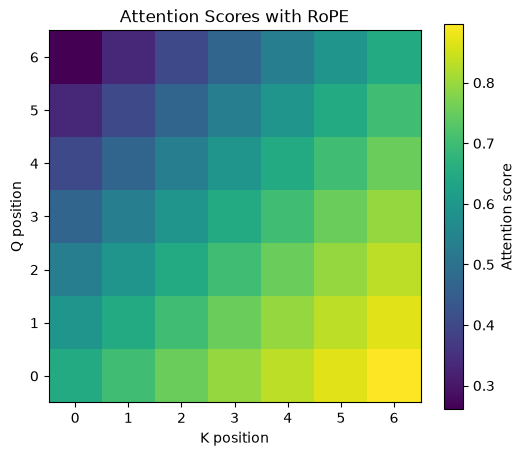

In [1]:
import torch
import matplotlib.pyplot as plt

q = torch.tensor([1.0, 0.5])
k = torch.tensor([0.8, -0.3])

theta = torch.pi / 40
positions = torch.arange(7)


def rotate(x, angle):
    c = torch.cos(angle)
    s = torch.sin(angle)

    R = torch.tensor([
        [c, -s],
        [s,  c]
    ])

    return R @ x


# 计算加入 RoPE 后的注意力分数
scores = torch.zeros(7, 7)

for m in positions:
    for n in positions:
        q_rot = rotate(q, m * theta)
        k_rot = rotate(k, n * theta)

        scores[m, n] = q_rot @ k_rot


# 可视化
plt.figure(figsize=(6, 5))

plt.imshow(
    scores.numpy(),
    origin="lower",
    aspect="equal"
)

plt.xticks(positions)
plt.yticks(positions)

plt.xlabel("K position")
plt.ylabel("Q position")
plt.title("Attention Scores with RoPE")

plt.colorbar(label="Attention score")

plt.show()

将得到的注意力分数画成热力图后，可以看到明显的对角线结构。

这是因为同一条对角线上的位置组合具有相同的相对位置。例如，位置组合 $(0,2)$ 和 $(1,3)$ 分别对应

$$
n-m=2
$$

虽然它们的绝对位置不同，但 Q 和 K 之间的旋转角度差相同，因此得到的注意力分数也相同。

类似地，对于任意满足

$$
n-m=d
$$

的位置组合，它们对应的注意力分数都相同。因此，在热力图中，相同相对位置的点会落在同一条对角线上，并呈现出相同的数值。

这与前面的推导完全一致

$$
s_{mn}'=q^\top R((n-m)\theta)k
$$

其中真正决定旋转关系的不是 $m$ 和 $n$ 各自的绝对位置，而是它们之间的差 $n-m$。

因此，从演示中，我们可以直观地观察到 RoPE 引入的相对位置性质：

$$
\boxed{\text{相同的相对位置}
\Longrightarrow
\text{相同的旋转关系}
\Longrightarrow
\text{相同的注意力分数}}
$$


## 4. 旋转的复数表示

前面我们从二维向量出发，用旋转矩阵表示位置编码。对于二维向量来说，旋转本身有一个非常简洁的复数表示。

将二维向量

$$
x=
\begin{bmatrix}
x_1\\
x_2
\end{bmatrix}
$$

对应到复数

$$
z=x_1+i x_2
$$

其中 $i^2=-1$。

根据欧拉公式

$$
e^{i\theta}=\cos\theta+i\sin\theta
$$

复数乘法

$$
z'=ze^{i\theta}
$$

恰好就对应于将二维向量旋转 $\theta$ 角度。

因此，前面使用旋转矩阵表示的过程，也可以写成复数形式。假设 token 位于位置 $m$，那么经过位置旋转后

$$
z'=ze^{im\theta}
$$

对于一个高维 token 表示，我们可以将它拆分成多个二维向量，并分别看成多个复数。

设 token 的表示维度为 $d$，其中 $d$ 为偶数。将向量

$$
x=
\begin{bmatrix}
x_1&
x_2&
\cdots&
x_d
\end{bmatrix}^{\top}
$$

重新看成 $d/2$ 个复数。令向量的前半部分表示复数的实部，后半部分对应虚部，
那么每一个复数都可以表示为

$$
z_j=x_j+i x_{j+d/2}
$$

其中

$$
j=1,2,\ldots,\frac d2
$$

于是，一个原本的 $d$ 维实向量，就可以等价地表示成

$$
z=
\begin{bmatrix}
z_1&
z_2&
\cdots&
z_{d/2}
\end{bmatrix}
$$

也就是说，我们不再把 token 看成一条单纯的实数向量，而是把它看成由多个复数组成的。

这样做的好处是，RoPE 中的旋转可以直接作用在每一个复数上。对于第 $j$ 个复数，在位置 $m$ 时可以写成

$$
z_j'=z_j e^{im\theta_j}
$$

其中 $\theta_j$ 表示第 $j$ 个复数对应的旋转频率。

于是，一个 token 在不同位置上的表示，可以理解为多个复数同时发生不同程度的相位旋转。

下一个问题：为什么要让**不同的复数使用不同的 $\theta_j$**？这就会自然引出 RoPE 中的多频率设计。


## 5. 多频率旋转

### 5.1 单频率 vs 多频率

我们已经可以用一个频率 $\theta$ 对位置进行编码：

$$
z'=ze^{im\theta}
$$

但如果始终只使用一个频率，就会遇到一个问题：旋转是具有周期性的。

因为

$$
e^{i(\phi+2\pi)}=e^{i\phi}
$$

所以当两个位置之间的距离达到某个周期后，它们对应的相位就会重新回到相同的位置（或者异常接近）。单一频率因此无法无限区分不同的相对位置。

一个自然的想法是把频率设置得非常低，从而让周期变得很大。这样可以把位置重复的问题推得很远，但又会产生另一个问题：相邻位置之间的旋转角度变得很小。

对于位置 $m$ 和 $m+1$，两者的相位差为

$$
\theta
$$

当 $\theta$ 很小时，相邻位置对应的相位变化也很小，因此模型很难区分相邻位置之间细微的位置差异。

于是，单一频率存在一个明显的取舍：

$$
\text{频率较高}
\Longrightarrow
\text{局部位置变化明显}
\Longrightarrow
\text{周期较短}
$$

$$
\text{频率较低}
\Longrightarrow
\text{周期较长}
\Longrightarrow
\text{局部位置变化较小}
$$

也就是说，单独使用一个频率，很难同时兼顾短距离上的精细位置变化和长距离上的位置区分。

因此，我们可以不再让所有复数使用同一个频率，而是让不同的复数使用不同的频率：

$$
z_j'=z_j e^{im\theta_j}
$$

其中 $\theta_j$ 表示第 $j$ 个复数对应的旋转频率。

这样一来，不同频率就能够从不同的尺度观察位置变化。较高的频率对局部位置变化更加敏感，而较低的频率能够在更大的位置范围内保持区分能力。

因此，RoPE 使用多个频率，本质上是在构造一种多尺度的位置表示：

$$
\boxed{
\text{多个频率}
\Longrightarrow
\text{多个位置尺度}
\Longrightarrow
\text{同时感受局部与长程的位置变化}
}
$$

接下来需要进一步看看，这些频率具体是如何安排的，以及 RoPE 中的 $\theta_j$ 为什么采用特定的变化规律。


### 5.2 频率分布

我们已经让不同的复数使用不同的频率：

$$
z_j'=z_j e^{im\theta_j}
$$

既然希望使用多个频率来感知不同尺度的位置变化，一个最自然的想法是让频率均匀分布。

例如，希望在

$$
\theta\in[0.001,1]
$$

这个范围内选择 $4$ 个频率。如果按照线性方式均匀取值，就得到

$$
\begin{align*}
\theta_0
&=
0.001\\
\theta_1
&\approx
0.334\\
\theta_2
&\approx
0.667\\
\theta_3
&=
1
\end{align*}
$$

但频率对应的位置尺度与周期

$$
T=\frac{2\pi}{\theta}
$$

成反比，因此这四个频率对应的周期大约为

$$
6283,\quad
18.8,\quad
9.4,\quad
6.3
$$

可以看到，虽然频率在线性轴上均匀分布，但对应的位置尺度却非常不均衡。$6.3$、$9.4$ 和 $18.8$ 都集中在较短的尺度，而从 $18.8$ 到 $6283$ 之间却几乎没有其他频率。

这意味着，如果我们只有有限数量的频率，线性均匀分布会让大量频率集中在相近的短尺度上，而不同数量级的长距离尺度之间缺乏足够的表示。

但我们真正希望的是让频率覆盖的位置尺度尽可能广，并且在不同数量级上都能够得到感知。

而在 RoPE 中，这些频率并不是随意选择的，而是按照对数尺度均匀分布。频率可以写成

$$
\theta_j=\mathrm{base}^{-2j/d}
$$

取对数后得到

$$
\log\theta_j=-\frac{2j}{d}\log\mathrm{base}
$$

因此，$\theta_j$ 是在 $(\text{base}^{-1},1]$ 的对数均匀分布，且 $j$ 越大，对应频率越慢。

较高的频率能够更加敏感地感知局部位置变化，而较低的频率则能够覆盖更大的位置范围。

对应的周期为

$$
T_j=\frac{2\pi}{\theta_j}
$$

代入频率公式可得

$$
T_j=2\pi\,\mathrm{base}^{2j/d}
$$

因此，$T_j$ 是在 $[2\pi,2\pi \text{base})$ 的对数均匀分布，且 $j$ 越大，对应更长的周期。
$\mathrm{base}$ 越大，频率所覆盖的尺度范围就越大，尤其是低频部分能够覆盖更长距离的位置变化。

所以，$\mathrm{base}$ 可以理解为控制位置编码所覆盖尺度范围的一个重要参数：

$$
\mathrm{base}\uparrow
\Longrightarrow
\text{可覆盖的尺度范围更大}
$$

因此，多个频率实际上构成了一个多尺度的位置表示：

$$
\boxed{
\text{对数均匀分布的多个频率}
\Longrightarrow
\text{覆盖不同的位置尺度}
\Longrightarrow
\text{同时感知局部与长程的位置变化}
}
$$

结合前面的多频率设计，RoPE 最终得到的是一组在对数尺度上分布的频率，它们共同让位置表示能够覆盖从局部到长程的不同尺度。


## 6. 重新理解代码实现

### 6.1 rotate_half

前面我们已经把二维向量表示成复数

$$
z=x+iy
$$

并且利用欧拉公式

$$
e^{i\theta}=\cos\theta+i\sin\theta
$$

将位置 $\theta$ 对应的旋转写成复数乘法

$$
z'=ze^{i\theta}
$$

将其展开，可以得到

$$
\begin{align*}
z'
&=
z(\cos\theta+i\sin\theta)\\
&=
z\cos\theta+iz\sin\theta
\end{align*}
$$

复数乘以 $i$ 的作用是

$$
x+iy
\longrightarrow
-y+ix
$$

也就是

$$
(x,y)
\longrightarrow
(-y,x)
$$

因此，如果我们使用实数 Tensor 来保存复数的实部和虚部，那么只需要将实部与虚部交换，并对原来的虚部取负，就可以实现乘以 $i$ 的操作。

假设一个向量的前一半保存复数的实部，后一半保存虚部，就以 Qwen3 中 $d=128$ 为例

$$
x=
\begin{bmatrix}
x_0&
x_1&
\cdots&
x_{127}
\end{bmatrix}^{\top}
$$

这样可以将它表示成 $64$ 个复数

$$
z_j=x_j+i x_{j+64}
\qquad
j=0,1,\ldots,63
$$

对于其中任意一个复数

$$
z_j=x_j+i x_{j+64}
$$

乘以虚数单位 $i$ 后，有

$$
\begin{align*}
iz_j
&=
i(x_j+i x_{j+64})\\
&=
-x_{j+64}+ix_j
\end{align*}
$$

也就是说，在实数 Tensor 中，只需要将前后两部分交换，并对原来的后 $64$ 个维度取负：

$$
\begin{bmatrix}
x_0\\
x_1\\
\vdots\\
x_{63}\\
x_{64}\\
x_{65}\\
\vdots\\
x_{127}
\end{bmatrix}
\quad\xrightarrow{\ \operatorname{rotate\_ half}\ }\quad
\begin{bmatrix}
-x_{64}\\
-x_{65}\\
\vdots\\
-x_{127}\\
x_0\\
x_1\\
\vdots\\
x_{63}
\end{bmatrix}
$$

在 Qwen3 的实现中，这正是 rotate_half 所完成的事情：

```python
def rotate_half(x):
    x1 = x[..., :x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2:]
    return torch.cat((-x2, x1), dim=-1)
```

因此可以把

```python
rotate_half(x)
```

直接理解成对这 $64$ 个复数同时执行

$$
z_j\longrightarrow iz_j
$$

即

$$
\boxed{\operatorname{rotate\_half}(x)\equiv ix}
$$

### 6.2 cos / sin 表

实际计算时，我们会同时对所有位置的Q和K进行旋转。

Q和K的尺寸都是 $[S,128]$，其中 $S$ 为序列的长度。

前面我们已经把一个 $128$ 维向量看成 $64$ 个复数

$$
z_j=x_j+i x_{j+64}
\qquad
j=0,1,\ldots,63
$$

在位置 $m$ 时，第 $j$ 个复数需要旋转的角度为

$$
m\theta_j
$$

因此，它实际进行的是

$$
z_{m,j} \longrightarrow z_{m,j}\cos(m\theta_j)+iz_{m,j}\sin(m\theta_j)
$$

所以，对于每一个位置 $m$ 和每一个频率 $\theta_j$，我们都需要分别计算

$$
\cos(m\theta_j)
$$

和

$$
\sin(m\theta_j)
$$

这实际上可以看成两张表。

例如，假设我们只考虑位置

$$
m=0,1,\ldots,6
$$

以及 $64$ 个旋转频率，那么 cos 表可以理解为

$$
\begin{array}{c|cccc}
 & \theta_0 & \theta_1 & \cdots & \theta_{63}\\
\hline
0 & \cos(0\theta_0) & \cos(0\theta_1) & \cdots & \cos(0\theta_{63})\\
1 & \cos(1\theta_0) & \cos(1\theta_1) & \cdots & \cos(1\theta_{63})\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
6 & \cos(6\theta_0) & \cos(6\theta_1) & \cdots & \cos(6\theta_{63})
\end{array}
$$

对应地，sin 表为

$$
\begin{array}{c|cccc}
 & \theta_0 & \theta_1 & \cdots & \theta_{63}\\
\hline
0 & \sin(0\theta_0) & \sin(0\theta_1) & \cdots & \sin(0\theta_{63})\\
1 & \sin(1\theta_0) & \sin(1\theta_1) & \cdots & \sin(1\theta_{63})\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
6 & \sin(6\theta_0) & \sin(6\theta_1) & \cdots & \sin(6\theta_{63})
\end{array}
$$

因此，这两张表的核心就是计算

$$
m\theta_j
$$

再分别取 $\cos$ 和 $\sin$。

因此，对于每一个位置 $m$，我们都需要把它和全部 $64$ 个频率分别相乘。

例如，当序列长度为 $7$ 时，位置为

$$
m=0,1,\ldots,6
$$

那么所有位置和所有频率对应的旋转角度可以排成一张表

$$
\begin{array}{c|cccc}
 & \theta_0 & \theta_1 & \cdots & \theta_{63}\\
\hline
0 & 0\theta_0 & 0\theta_1 & \cdots & 0\theta_{63}\\
1 & 1\theta_0 & 1\theta_1 & \cdots & 1\theta_{63}\\
2 & 2\theta_0 & 2\theta_1 & \cdots & 2\theta_{63}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
6 & 6\theta_0 & 6\theta_1 & \cdots & 6\theta_{63}
\end{array}
$$

这张表就是后面计算 $\cos$ 和 $\sin$ 的基础。

将所有位置组成列向量

$$
p=
\begin{bmatrix}
0\\
1\\
\vdots\\
6
\end{bmatrix}
$$

将 $64$ 个旋转频率组成行向量

$$
\theta=
\begin{bmatrix}
\theta_0&
\theta_1&
\cdots&
\theta_{63}
\end{bmatrix}
$$

则所有位置与所有频率对应的旋转角度，可以通过二者的外积一次性得到

$$
\begin{aligned}
\underbrace{
\begin{bmatrix}
0\\
1\\
2\\
3\\
4\\
5\\
6
\end{bmatrix}
}_{7}
\;\otimes\;
\underbrace{
\begin{bmatrix}
\theta_0 & \theta_1 & \theta_2 & \cdots & \theta_{63}
\end{bmatrix}
}_{64}
&=
\underbrace{
\begin{bmatrix}
0\theta_0 & 0\theta_1 & 0\theta_2 & \cdots & 0\theta_{63}\\
1\theta_0 & 1\theta_1 & 1\theta_2 & \cdots & 1\theta_{63}\\
2\theta_0 & 2\theta_1 & 2\theta_2 & \cdots & 2\theta_{63}\\
3\theta_0 & 3\theta_1 & 3\theta_2 & \cdots & 3\theta_{63}\\
4\theta_0 & 4\theta_1 & 4\theta_2 & \cdots & 4\theta_{63}\\
5\theta_0 & 5\theta_1 & 5\theta_2 & \cdots & 5\theta_{63}\\
6\theta_0 & 6\theta_1 & 6\theta_2 & \cdots & 6\theta_{63}
\end{bmatrix}
}_{7\times64}
\end{aligned}
$$


其中第 $m$ 行、第 $j$ 列的元素就是

$$
\mathrm{freqs}_{m,j}=m\theta_j
$$

因此，当序列长度为 $S$ 时，`freqs` 的形状为

$$
S\times64
$$

在代码中，这一步可以直接写成

```python
# 外积：[B, head_dim/2, 1] @ [B, 1, S] -> [B, head_dim/2, S] -> transpose -> [B, S, head_dim/2]
inv_freq_expanded = inv_freq[None, :, None].expand(position_ids.shape[0], -1, 1)
positions_expanded = position_ids[:, None, :].float()
freqs = (inv_freq_expanded @ positions_expanded).transpose(1, 2)
```

这里 `position_ids` 的形状为 `[S]`，`inv_freq` 的形状为 `[64]`，外积后得到 `[S, 64]` 的角度表。

得到 `freqs` 后，此时它的尺寸为 $[S,64]$，但是Q和K的尺寸都是 $[S,128]$，无法逐元素相乘。

这是因为一个 $128$ 维向量对应 $64$ 个复数，而每个复数都有实部和虚部，所以同一个旋转角度需要同时作用于这两个部分。

因此将 `freqs` 扩展到 $128$ 维：

```python
emb = torch.cat((freqs, freqs), dim=-1)      # [B, S, head_dim]
```

于是

$$
[S,64]\rightarrow[S,128]
$$

前 $64$ 个值对应复数的实部，后 $64$ 个值对应虚部，但两部分使用的是**同一组旋转角度**。

最后分别计算余弦表和正弦表，对应代码中

```python
return emb.cos().to(dtype), emb.sin().to(dtype), inv_freq
```

### 6.3 Q 和 K 进行旋转

$$q' = q \odot \cos + \mathrm{rotate\_half}(q) \odot \sin$$

$$k' = k \odot \cos + \mathrm{rotate\_half}(k) \odot \sin$$

对应代码中

```python
q_out = q * cos + my_rotate_half(q) * sin
k_out = k * cos + my_rotate_half(k) * sin
```

## 小结

到这里，我们已经从数学和小规模实验两个层面观察了 RoPE 的性质：它通过旋转将位置信息引入 QK 内积，并使注意力分数显式依赖两个 token 的相对位置。

但这些实验仍然不能说明 RoPE 一定能够提升模型的实际能力。

如果希望验证一个结构对模型能力的影响，就需要进一步进行模型训练和对照实验。最直接的方法，是保持模型规模、训练数据、优化方法和训练预算等条件一致，只改变位置编码方式，然后比较训练过程和最终模型在特定任务上的表现。

$$
\boxed{
\text{只改变结构}
\Longrightarrow
\text{训练多个对照模型}
\Longrightarrow
\text{比较模型行为}
}
$$

例如，可以比较使用 RoPE、其他位置编码方式以及不使用显式位置编码的 Transformer，并在语言建模、推理任务或长度泛化任务上进行评估。

这类实验才真正能够回答：

$$
\text{RoPE 的数学性质}
\quad\longrightarrow\quad
\text{是否转化成了模型能力上的差异}
$$

RoFormer 的原始工作已经通过下游任务比较展示了 RoPE 的经验效果，而后续关于位置编码和长度泛化的研究则进一步表明，不同位置编码方案的表现取决于具体任务和训练设置，因此不能仅凭数学上的优良性质推断其在所有模型中的能力提升。

因此，本实验到这里暂时停在“理解 RoPE 如何工作”这一层。至于它为什么能够在实际模型中产生怎样的能力，以及这种能力是否可以归因于 RoPE，则应该交给模型训练和论文中的消融实验来回答。
